Importing the basic libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Load Dataset from Local Directory

In [66]:
from google.colab import files
uploaded = files.upload()

Saving DataSetA.csv to DataSetA.csv


Importing the dataset

In [86]:
dataset = pd.read_csv('DataSetA.csv')

ParserError: Error tokenizing data. C error: Expected 7 fields in line 12, saw 9


In [68]:
dataset

,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
0,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,low fat yogurt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,butter,light mayo,fresh bread,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7496,burgers,frozen vegetables,eggs,french fries,magazines,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7497,chicken,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7498,escalope,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
transactions = dataset.values.astype(str).tolist()

Data Pre-Processing

In [70]:
transactions = []
for i in range(0, 7500):
  transactions.append([str(dataset.values[i,j]) for j in range(0, 20)])
transactions

[['burgers',
  'meatballs',
  'eggs',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan'],
 ['chutney',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan'],
 ['turkey',
  'avocado',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan'],
 ['mineral water',
  'milk',
  'energy bar',
  'whole wheat rice',
  'green tea',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan'],
 ['low fat yogurt',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan',
  'nan'],
 ['whole wheat pasta',
  

Training APRIORI

In [77]:

!pip install apyori
from apyori import apriori
rules = apriori(transactions = transactions, min_support = 0.003, min_confidence = 0.2, min_lift = 3, min_length = 2, max_length = 2)

In [78]:
results = list(rules)

In [79]:
results

[RelationRecord(items=frozenset({'light cream', 'chicken'}), support=0.004533333333333334, ordered_statistics=[OrderedStatistic(items_base=frozenset({'light cream'}), items_add=frozenset({'chicken'}), confidence=0.2905982905982906, lift=4.843304843304844)]),
 RelationRecord(items=frozenset({'mushroom cream sauce', 'escalope'}), support=0.005733333333333333, ordered_statistics=[OrderedStatistic(items_base=frozenset({'mushroom cream sauce'}), items_add=frozenset({'escalope'}), confidence=0.30069930069930073, lift=3.7903273197390845)]),
 RelationRecord(items=frozenset({'pasta', 'escalope'}), support=0.005866666666666667, ordered_statistics=[OrderedStatistic(items_base=frozenset({'pasta'}), items_add=frozenset({'escalope'}), confidence=0.37288135593220345, lift=4.700185158809287)]),
 RelationRecord(items=frozenset({'fromage blanc', 'honey'}), support=0.0033333333333333335, ordered_statistics=[OrderedStatistic(items_base=frozenset({'fromage blanc'}), items_add=frozenset({'honey'}), confiden

Results in Dataframe

In [80]:
lhs         = [tuple(result[2][0][0])[0] for result in results]
rhs         = [tuple(result[2][0][1])[0] for result in results]
supports    = [result[1] for result in results]
confidences = [result[2][0][2] for result in results]
lifts       = [result[2][0][3] for result in results]
resultsinDataFrame = pd.DataFrame(zip(lhs, rhs, supports, confidences, lifts), columns = ['Left Hand Side', 'Right Hand Side', 'Support', 'Confidence', 'Lift'])
resultsinDataFrame

,Left Hand Side,Right Hand Side,Support,Confidence,Lift
0,light cream,chicken,0.004533,0.290598,4.843305
1,mushroom cream sauce,escalope,0.005733,0.300699,3.790327
2,pasta,escalope,0.005867,0.372881,4.700185
3,fromage blanc,honey,0.003333,0.245098,5.178128
4,herb & pepper,ground beef,0.016000,0.323450,3.291555
5,tomato sauce,ground beef,0.005333,0.377358,3.840147
6,light cream,olive oil,0.003200,0.205128,3.120612
7,whole wheat pasta,olive oil,0.008000,0.271493,4.130221
8,pasta,shrimp,0.005067,0.322034,4.514494


In [81]:
resultsinDataFrame.nlargest(n = 10, columns = 'Lift')

,Left Hand Side,Right Hand Side,Support,Confidence,Lift
3,fromage blanc,honey,0.003333,0.245098,5.178128
0,light cream,chicken,0.004533,0.290598,4.843305
2,pasta,escalope,0.005867,0.372881,4.700185
8,pasta,shrimp,0.005067,0.322034,4.514494
7,whole wheat pasta,olive oil,0.008000,0.271493,4.130221
5,tomato sauce,ground beef,0.005333,0.377358,3.840147
1,mushroom cream sauce,escalope,0.005733,0.300699,3.790327
4,herb & pepper,ground beef,0.016000,0.323450,3.291555
6,light cream,olive oil,0.003200,0.205128,3.120612


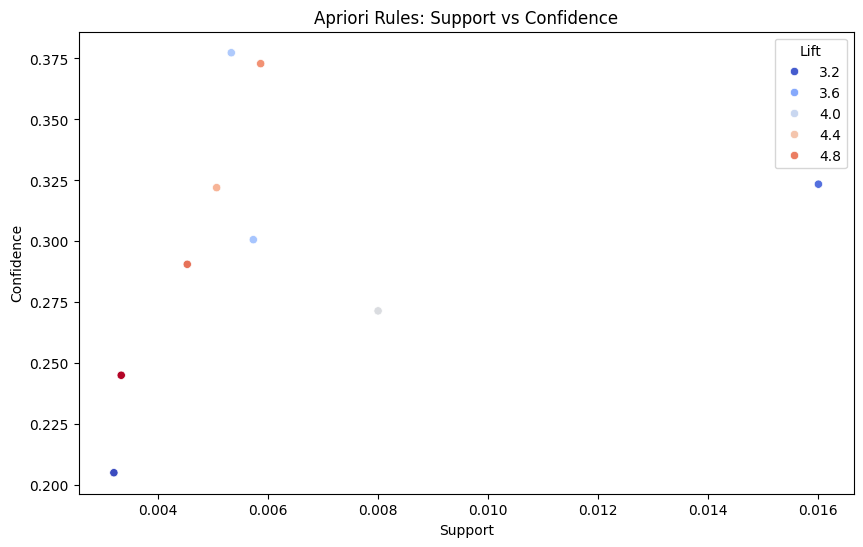

In [85]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Support', y='Confidence', data=resultsinDataFrame, hue='Lift', palette='coolwarm',  sizes=(20, 200))
plt.title('Apriori Rules: Support vs Confidence')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.show()
